In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize

In [2]:
EJ = 1.5
EC = 1.46*0.5
EL = 0.23*0.5

qubit_level = 40

def get_shift(ele,Delta_ij):
    return abs(ele)**2 / Delta_ij

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    points_nearby = []
    Er = x
    shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
        
    return abs(shift_from_one-shift_from_two)

initial_guess = [7.14]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.7199592513977846e-06
             x: [ 7.135e+00]
           nit: 13
          nfev: 27
 final_simplex: (array([[ 7.135e+00],
                       [ 7.135e+00]]), array([ 1.720e-06,  2.326e-06]))
Optimal solution: [7.13459619]
Objective value: 1.7199592513977846e-06


In [5]:
from utils import *

In [6]:
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = 0.3,
    qubit_level = 40,
    osc_level = 40,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(30) for ol in range(40) ]
    )
energies=  system.hilbertspace.eigenvals(1200)


energies[5]-energies[0], energies[7]-energies[0],   energies[9]-energies[0]

(4.636241604344044, 6.677266902624378, 8.016573466338507)


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.2030451314840871
qbt freq at osc 1:	0.20289, 	diff to at osc ground -0.00016, 0.0769% diff
qbt freq at osc 2:	0.20274, 	diff to at osc ground -0.00031, 0.1526% diff
qbt freq at osc 3:	0.20258, 	diff to at osc ground -0.00046, 0.2271% diff
qbt freq at osc 4:	0.20244, 	diff to at osc ground -0.00061, 0.3002% diff
qbt freq at osc 5:	0.20229, 	diff to at osc ground -0.00076, 0.3722% diff
qbt freq at osc 6:	0.20215, 	diff to at osc ground -0.00090, 0.4428% diff
qbt freq at osc 7:	0.20201, 	diff to at osc ground -0.00104, 0.5121% diff
qbt freq at osc 8:	0.20187, 	diff to at osc ground -0.00118, 0.5802% diff
qbt freq at osc 9:	0.20173, 	diff to at osc ground -0.00131, 0.6470% diff
qbt freq at osc 10:	0.20160, 	diff to at osc ground -0.00145, 0.7124% diff
qbt freq at osc 11:	0.20147, 	diff to at osc ground -0.00158, 0.7766% diff
qbt freq at osc 12:	0.20134, 	diff to at osc ground -0.00170, 0.8394% di

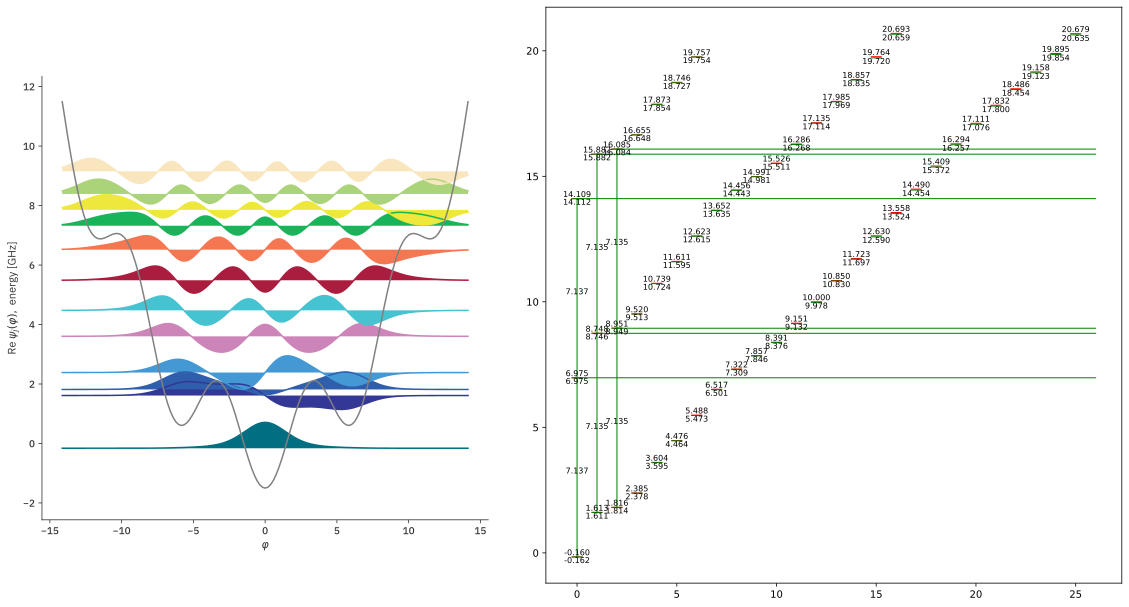

In [12]:


def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,29):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,10):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)